# The next microstructure-ML techniques

## A small, runnable laboratory on real local SEM data

This notebook turns the proposed research programme into eight compact
demonstrations:

1. masked and contrastive self-supervised learning;
2. physically scale-aware image representations;
3. attention-based multiple-instance learning;
4. message passing on carbide entity graphs;
5. teacher–student semi-supervised segmentation;
6. multimodal image + process property prediction;
7. cross-domain feature alignment;
8. registered local property mapping, conformal uncertainty, and active learning.

Most sections use the real IN718 SEM images and supplied ImageJ carbide
masks already on disk. The final spatial-hardness section uses a
**clearly labelled simulated hardness field over a real SEM/mask**. It
demonstrates the workflow we could run after a registered indentation
campaign; it is not a mechanical-property result.

The emphasis is on visible mechanics and honest validation, not
state-of-the-art performance from a short demonstration run.

In [1]:
from __future__ import annotations

import copy
import io
import math
import re
from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib.patches import Rectangle
from PIL import Image
from scipy import ndimage
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    balanced_accuracy_score,
    mean_absolute_error,
)
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from microhard.entity_graph import (
    normalise_grayscale,
    region_graph_from_mask,
)

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data"

NAVY = "#17324D"
BLUE = "#3A6EA5"
TEAL = "#2A9D8F"
GOLD = "#E9C46A"
ORANGE = "#F4A261"
RED = "#E76F51"
SLATE = "#607080"
PALE = "#EEF4F7"
MATERIAL_COLOURS = {"A": NAVY, "B": TEAL, "C": ORANGE, "D": RED}

plt.rcParams.update(
    {
        "figure.dpi": 125,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.18,
        "legend.frameon": False,
    }
)

torch.manual_seed(47)
np.random.seed(47)
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)


def clean_axis(axis):
    axis.grid(axis="y", alpha=0.18)
    axis.spines["left"].set_color("#A9B4BC")
    axis.spines["bottom"].set_color("#A9B4BC")


def crop_at(
    array: np.ndarray,
    centre_y: int,
    centre_x: int,
    *,
    crop_size: int,
    output_size: int = 64,
) -> np.ndarray:
    height, width = array.shape
    half = crop_size // 2
    top = int(np.clip(centre_y - half, 0, max(0, height - crop_size)))
    left = int(np.clip(centre_x - half, 0, max(0, width - crop_size)))
    patch = array[top : top + crop_size, left : left + crop_size]
    if patch.shape != (output_size, output_size):
        patch = np.asarray(
            Image.fromarray(np.round(255 * patch).astype(np.uint8)).resize(
                (output_size, output_size),
                Image.Resampling.BILINEAR,
            )
        ).astype(np.float32) / 255.0
    return np.ascontiguousarray(patch, dtype=np.float32)


def field_key(pair: dict) -> str:
    return f"{pair['material']}{pair['field']}"


print(f"Repository: {ROOT}")
print(f"Device: {DEVICE}")

Repository: /Users/jameshansen/Microstructural prediction/microhard
Device: mps


## 1 · One audited dataset, several learning views

The carbide archive contains 14 raw-image/mask pairs and 65 raw
carbide-focused SEM fields. Ten labelled fields form the downstream
training set. Four complete fields—one per material variant—are never
used in self-supervision, segmentation training, MIL training, or GNN
training.

This lets each technique see a different view of the same physical
evidence:

- pixels for representation learning;
- bags of patches for MIL;
- connected carbide regions for graphs;
- masks for supervised and semi-supervised segmentation.

In [2]:
carbide_archive = (
    DATA
    / "public_in718_carbides_2025"
    / "raw"
    / "04_Microscopy.zip"
)
validation_keys = {("A", "005"), ("B", "005"), ("C", "004"), ("D", "035")}


def discover_mask_records(path: Path) -> list[dict]:
    with ZipFile(path) as archive:
        names = set(archive.namelist())
    records = []
    for mask_member in sorted(
        name
        for name in names
        if name.lower().endswith("_binary.tif")
        and "SEM carbides binarized" in name
    ):
        filename = Path(mask_member).name.removeprefix("Drawing of ")
        image_name = filename.replace("_binary.tif", ".tif")
        image_member = str(Path(mask_member).parent / image_name)
        match = re.search(r"_(\d+)_binary\.tif$", filename)
        if image_member in names and match:
            records.append(
                {
                    "material": filename[0],
                    "field": match.group(1),
                    "image_member": image_member,
                    "mask_member": mask_member,
                }
            )
    return records


def load_pair(archive: ZipFile, record: dict) -> dict:
    image_pil = Image.open(io.BytesIO(archive.read(record["image_member"])))
    image_pil.load()
    mask_pil = Image.open(io.BytesIO(archive.read(record["mask_member"])))
    mask_pil.load()
    image = normalise_grayscale(
        np.asarray(image_pil.convert("L"))
    ).astype(np.float32)
    mask = np.asarray(mask_pil.convert("L")) < 128
    height = min(image.shape[0], mask.shape[0])
    width = min(image.shape[1], mask.shape[1])
    resolution = mask_pil.info.get("resolution", (18.0, 18.0))
    return {
        **record,
        "image": image[:height, :width],
        "mask": mask[:height, :width],
        "pixel_size_um": 1.0 / float(resolution[0]),
    }


mask_records = discover_mask_records(carbide_archive)
with ZipFile(carbide_archive) as archive:
    carbide_pairs = [load_pair(archive, record) for record in mask_records]
    archive_names = archive.namelist()

train_pairs = [
    pair
    for pair in carbide_pairs
    if (pair["material"], pair["field"]) not in validation_keys
]
test_pairs = [
    pair
    for pair in carbide_pairs
    if (pair["material"], pair["field"]) in validation_keys
]
heldout_members = {pair["image_member"] for pair in test_pairs}
unlabelled_members = sorted(
    name
    for name in archive_names
    if "SEM carbides binarized HT-treated/" in name
    and Path(name).suffix.lower() in {".tif", ".tiff"}
    and "_binary" not in Path(name).stem.lower()
    and name not in heldout_members
)

audit = pd.DataFrame(
    [
        {"view": "labelled train fields", "count": len(train_pairs)},
        {"view": "whole-field tests", "count": len(test_pairs)},
        {
            "view": "eligible raw fields for SSL",
            "count": len(unlabelled_members),
        },
    ]
)
display(audit)
assert len(train_pairs) == 10 and len(test_pairs) == 4
assert heldout_members.isdisjoint(unlabelled_members)
print("Leakage audit passed: all four test fields are absent from pretraining.")

,view,count
0,labelled train fields,10
1,whole-field tests,4
2,eligible raw fields for SSL,61


Leakage audit passed: all four test fields are absent from pretraining.


## 2 · Self-supervision: masked reconstruction versus contrastive learning

Both models learn without material or property labels:

- the **masked autoencoder** reconstructs hidden image blocks;
- the **contrastive encoder** maps two augmented views of the same SEM
  crop close together and different crops farther apart.

A frozen linear probe then tests whether the representations separate
the A–D material variants on four whole fields excluded from
pretraining. A third probe concatenates fine and contextual views,
illustrating a physically scale-aware representation.

In [3]:
ssl_rng = np.random.default_rng(47)
ssl_patches = []
with ZipFile(carbide_archive) as archive:
    for member in unlabelled_members:
        image_pil = Image.open(io.BytesIO(archive.read(member)))
        image_pil.load()
        array = normalise_grayscale(
            np.asarray(image_pil.convert("L"))
        ).astype(np.float32)
        content_height = max(64, int(0.82 * array.shape[0]))
        for _ in range(4):
            centre_y = int(ssl_rng.integers(32, content_height - 32))
            centre_x = int(ssl_rng.integers(32, array.shape[1] - 32))
            ssl_patches.append(
                np.round(
                    255
                    * crop_at(
                        array,
                        centre_y,
                        centre_x,
                        crop_size=64,
                    )
                ).astype(np.uint8)
            )
ssl_patches = np.stack(ssl_patches)


def augment_patch(patch: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    view = patch.astype(np.float32) / 255.0
    view = np.rot90(view, int(rng.integers(4)))
    if rng.random() < 0.5:
        view = np.fliplr(view)
    if rng.random() < 0.5:
        view = np.flipud(view)
    contrast = float(rng.uniform(0.8, 1.2))
    brightness = float(rng.uniform(-0.08, 0.08))
    noise = rng.normal(0, 0.025, size=view.shape)
    return np.ascontiguousarray(
        np.clip(contrast * view + brightness + noise, 0, 1),
        dtype=np.float32,
    )


class MaskedPatchDataset(torch.utils.data.Dataset):
    def __init__(self, patches: np.ndarray, seed: int = 47):
        self.patches = patches
        self.seed = seed
        self.epoch = 0

    def __len__(self):
        return len(self.patches)

    def set_epoch(self, epoch: int):
        self.epoch = epoch

    def __getitem__(self, index: int):
        rng = np.random.default_rng(
            self.seed + self.epoch * len(self.patches) + index
        )
        target = augment_patch(self.patches[index], rng)
        blocks = rng.random((8, 8)) < 0.55
        mask = np.repeat(np.repeat(blocks, 8, axis=0), 8, axis=1)
        corrupted = target.copy()
        corrupted[mask] = rng.uniform(
            0.35, 0.65, np.count_nonzero(mask)
        )
        return (
            torch.from_numpy(corrupted[None]),
            torch.from_numpy(target[None]),
            torch.from_numpy(mask[None].astype(np.float32)),
        )


class ContrastivePatchDataset(torch.utils.data.Dataset):
    def __init__(self, patches: np.ndarray, seed: int = 71):
        self.patches = patches
        self.seed = seed
        self.epoch = 0

    def __len__(self):
        return len(self.patches)

    def set_epoch(self, epoch: int):
        self.epoch = epoch

    def __getitem__(self, index: int):
        rng_1 = np.random.default_rng(
            self.seed + self.epoch * len(self.patches) + index
        )
        rng_2 = np.random.default_rng(
            self.seed + 1_000_003 + self.epoch * len(self.patches) + index
        )
        return (
            torch.from_numpy(augment_patch(self.patches[index], rng_1)[None]),
            torch.from_numpy(augment_patch(self.patches[index], rng_2)[None]),
        )


class TinyEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(inplace=True),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

    def feature_map(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.features(inputs)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        features = self.feature_map(inputs)
        return F.adaptive_avg_pool2d(features, 1).flatten(1)


class TinyMaskedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = TinyEncoder()
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(16, 8, 4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(8, 1, 4, stride=2, padding=1),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder.feature_map(inputs))


class ContrastiveModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = TinyEncoder()
        self.projector = nn.Sequential(
            nn.Linear(32, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 16),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return F.normalize(self.projector(self.encoder(inputs)), dim=1)


def nt_xent(view_1: torch.Tensor, view_2: torch.Tensor, temperature=0.18):
    embeddings = torch.cat((view_1, view_2), dim=0)
    similarity = embeddings @ embeddings.T / temperature
    similarity.fill_diagonal_(-1e9)
    batch = len(view_1)
    target = torch.cat(
        (
            torch.arange(batch, 2 * batch, device=embeddings.device),
            torch.arange(0, batch, device=embeddings.device),
        )
    )
    return F.cross_entropy(similarity, target)


ssl_epochs = 6
masked_dataset = MaskedPatchDataset(ssl_patches)
contrastive_dataset = ContrastivePatchDataset(ssl_patches)
masked_loader = torch.utils.data.DataLoader(
    masked_dataset, batch_size=32, shuffle=True, num_workers=0
)
contrastive_loader = torch.utils.data.DataLoader(
    contrastive_dataset, batch_size=32, shuffle=True, num_workers=0
)

torch.manual_seed(47)
masked_model = TinyMaskedAutoencoder().to(DEVICE)
masked_optimizer = torch.optim.AdamW(masked_model.parameters(), lr=1e-3)
masked_history = []
for epoch in range(ssl_epochs):
    masked_dataset.set_epoch(epoch)
    losses = []
    masked_model.train()
    for corrupted, target, mask in masked_loader:
        corrupted, target, mask = (
            corrupted.to(DEVICE),
            target.to(DEVICE),
            mask.to(DEVICE),
        )
        masked_optimizer.zero_grad(set_to_none=True)
        reconstruction = torch.sigmoid(masked_model(corrupted))
        error = torch.abs(reconstruction - target)
        loss = 0.9 * (error * mask).sum() / mask.sum() + 0.1 * error.mean()
        loss.backward()
        masked_optimizer.step()
        losses.append(float(loss.detach().cpu()))
    masked_history.append(float(np.mean(losses)))

torch.manual_seed(47)
contrastive_model = ContrastiveModel().to(DEVICE)
contrastive_optimizer = torch.optim.AdamW(
    contrastive_model.parameters(), lr=1e-3
)
contrastive_history = []
for epoch in range(ssl_epochs):
    contrastive_dataset.set_epoch(epoch)
    losses = []
    contrastive_model.train()
    for view_1, view_2 in contrastive_loader:
        contrastive_optimizer.zero_grad(set_to_none=True)
        loss = nt_xent(
            contrastive_model(view_1.to(DEVICE)),
            contrastive_model(view_2.to(DEVICE)),
        )
        loss.backward()
        contrastive_optimizer.step()
        losses.append(float(loss.detach().cpu()))
    contrastive_history.append(float(np.mean(losses)))

torch.manual_seed(47)
random_encoder = TinyEncoder().to(DEVICE)
mae_encoder = masked_model.encoder
contrastive_encoder = contrastive_model.encoder
print(
    f"{len(ssl_patches):,} unlabelled crops; "
    f"masked loss {masked_history[0]:.3f} → {masked_history[-1]:.3f}; "
    f"contrastive loss {contrastive_history[0]:.3f} → "
    f"{contrastive_history[-1]:.3f}."
)

244 unlabelled crops; masked loss 0.201 → 0.130; contrastive loss 3.220 → 2.530.


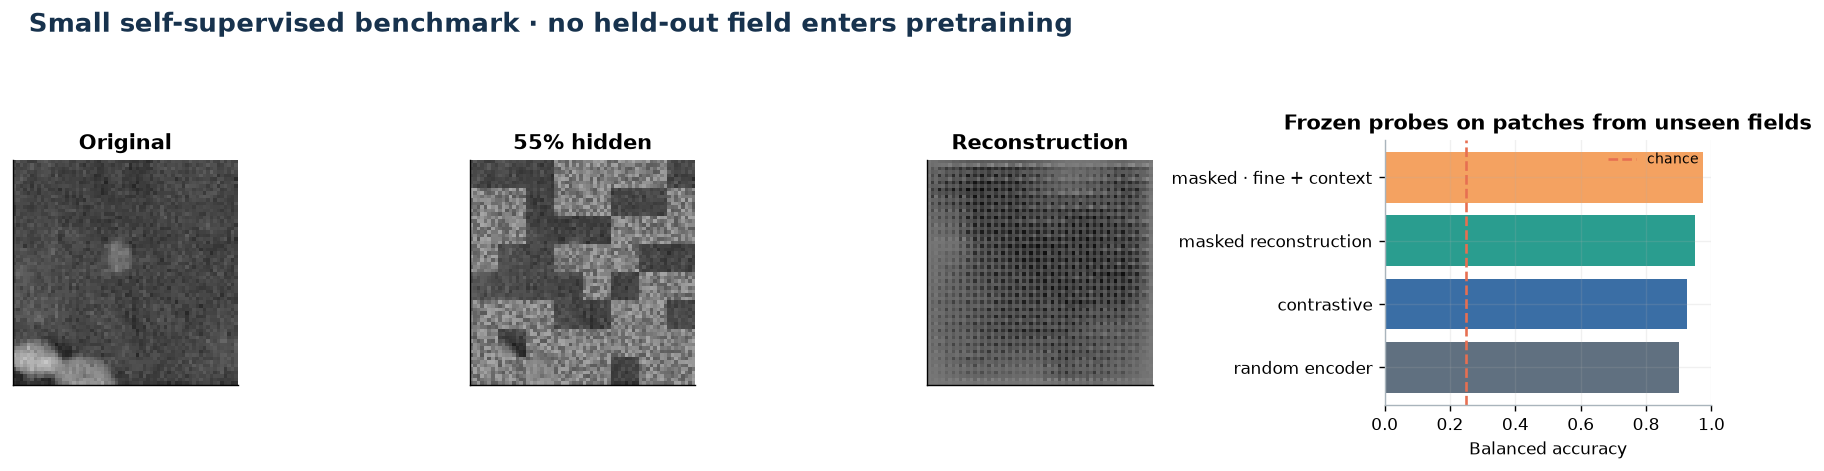

,held-out-field patch balanced accuracy
representation,
random encoder,0.900
masked reconstruction,0.950
contrastive,0.925
masked · fine + context,0.975


In [4]:
probe_fine = []
probe_context = []
probe_labels = []
probe_fields = []
probe_splits = []
probe_rng = np.random.default_rng(83)
material_to_index = {material: index for index, material in enumerate("ABCD")}

for pair in carbide_pairs:
    positives = np.argwhere(pair["mask"])
    content_height = int(0.82 * pair["image"].shape[0])
    for patch_index in range(10):
        if patch_index % 2 == 0 and len(positives):
            centre_y, centre_x = positives[
                int(probe_rng.integers(len(positives)))
            ]
        else:
            centre_y = int(probe_rng.integers(64, content_height - 64))
            centre_x = int(
                probe_rng.integers(64, pair["image"].shape[1] - 64)
            )
        probe_fine.append(
            crop_at(
                pair["image"],
                int(centre_y),
                int(centre_x),
                crop_size=64,
            )
        )
        probe_context.append(
            crop_at(
                pair["image"],
                int(centre_y),
                int(centre_x),
                crop_size=128,
            )
        )
        probe_labels.append(material_to_index[pair["material"]])
        probe_fields.append(field_key(pair))
        probe_splits.append(
            "test"
            if (pair["material"], pair["field"]) in validation_keys
            else "train"
        )

probe_fine = np.stack(probe_fine)
probe_context = np.stack(probe_context)
probe_labels = np.asarray(probe_labels)
probe_splits = np.asarray(probe_splits)


@torch.inference_mode()
def encode_arrays(encoder: nn.Module, arrays: np.ndarray) -> np.ndarray:
    encoder.eval()
    output = []
    for start in range(0, len(arrays), 64):
        tensor = torch.from_numpy(arrays[start : start + 64, None]).float()
        output.append(encoder(tensor.to(DEVICE)).cpu().numpy())
    return np.concatenate(output)


probe_rows = []
feature_sets = {}
for name, encoder in (
    ("random encoder", random_encoder),
    ("masked reconstruction", mae_encoder),
    ("contrastive", contrastive_encoder),
):
    feature_sets[name] = encode_arrays(encoder, probe_fine)
feature_sets["masked · fine + context"] = np.concatenate(
    (
        feature_sets["masked reconstruction"],
        encode_arrays(mae_encoder, probe_context),
    ),
    axis=1,
)

train_index = probe_splits == "train"
test_index = probe_splits == "test"
for name, features in feature_sets.items():
    probe = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            C=0.5,
            max_iter=3000,
            class_weight="balanced",
        ),
    )
    probe.fit(features[train_index], probe_labels[train_index])
    prediction = probe.predict(features[test_index])
    probe_rows.append(
        {
            "representation": name,
            "held-out-field patch balanced accuracy": balanced_accuracy_score(
                probe_labels[test_index], prediction
            ),
        }
    )
probe_results = pd.DataFrame(probe_rows).set_index("representation")

masked_dataset.set_epoch(ssl_epochs)
corrupted, target, _ = masked_dataset[3]
with torch.inference_mode():
    reconstructed = torch.sigmoid(
        masked_model(corrupted[None].to(DEVICE))
    )[0, 0].cpu().numpy()

fig, axes = plt.subplots(
    1,
    4,
    figsize=(14, 3.8),
    gridspec_kw={"width_ratios": [1, 1, 1, 1.45]},
)
for axis, image, title in zip(
    axes[:3],
    (target[0], corrupted[0], reconstructed),
    ("Original", "55% hidden", "Reconstruction"),
    strict=True,
):
    axis.imshow(image, cmap="gray", vmin=0, vmax=1)
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
values = probe_results[
    "held-out-field patch balanced accuracy"
].sort_values()
axes[3].barh(
    values.index,
    values,
    color=[SLATE, BLUE, TEAL, ORANGE],
)
axes[3].axvline(0.25, color=RED, linestyle="--", label="chance")
axes[3].set_xlim(0, 1)
axes[3].set_xlabel("Balanced accuracy")
axes[3].set_title("Frozen probes on patches from unseen fields")
axes[3].legend(fontsize=8)
clean_axis(axes[3])
fig.suptitle(
    "Small self-supervised benchmark · no held-out field enters pretraining",
    x=0.02,
    ha="left",
    color=NAVY,
    fontsize=15,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()
display(probe_results.round(3))

## 3 · Attention-based multiple-instance learning

A mechanical test belongs to a specimen, not to one arbitrarily chosen
SEM crop. Multiple-instance learning (MIL) treats all fields or patches
from a specimen as a variable-sized **bag**. A learned attention
function replaces indiscriminate averaging.

For this runnable demonstration, each complete SEM field is a bag of 12
fine/context patch pairs. The target is the real A–D material variant,
because exact specimen-level property targets do not exist for these 14
fields. The same architecture becomes a hardness regressor by replacing
the four-class output with one scalar.

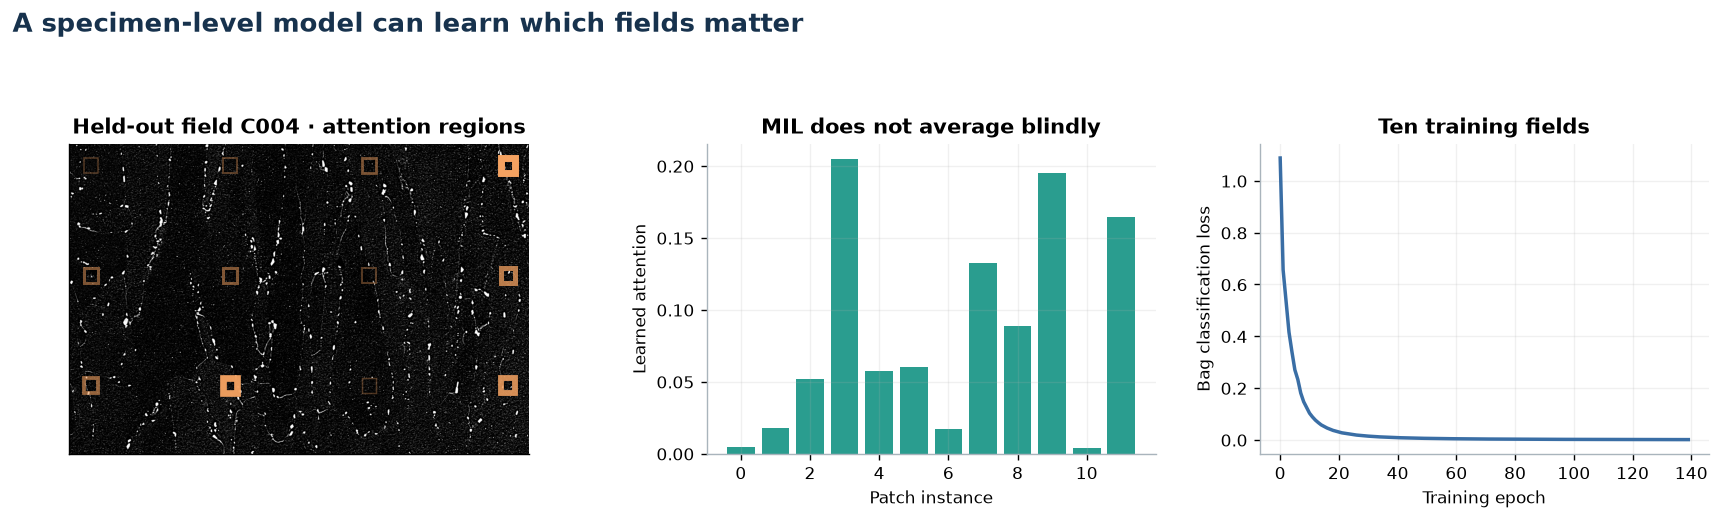

,field,split,observed material,predicted material,maximum patch attention
0,A004,train,A,A,0.084233
1,A005,test,A,A,0.087373
2,A007,train,A,A,0.089332
3,B003,train,B,B,0.221165
4,B005,test,B,B,0.247385
5,B006,train,B,B,0.183056
6,C000,train,C,C,0.136181
7,C001,train,C,C,0.384302
8,C002,train,C,C,0.234559
9,C003,train,C,C,0.221589


MIL material classification on four untouched fields: 100%. This is an architecture demonstration, not a property result.


In [5]:
def make_mil_bag(pair: dict) -> tuple[np.ndarray, list[tuple[int, int]]]:
    height, width = pair["image"].shape
    y_positions = np.linspace(96, int(0.78 * height), 3).astype(int)
    x_positions = np.linspace(96, width - 96, 4).astype(int)
    locations = [
        (int(y), int(x)) for y in y_positions for x in x_positions
    ]
    fine = np.stack(
        [
            crop_at(pair["image"], y, x, crop_size=64)
            for y, x in locations
        ]
    )
    context = np.stack(
        [
            crop_at(pair["image"], y, x, crop_size=128)
            for y, x in locations
        ]
    )
    # Physical scale is explicit even though this particular archive
    # happens to use a common calibration.
    scale_token = np.full(
        (len(locations), 1),
        np.log10(pair["pixel_size_um"]),
        dtype=np.float32,
    )
    embedding = np.concatenate(
        (
            encode_arrays(mae_encoder, fine),
            encode_arrays(mae_encoder, context),
            scale_token,
        ),
        axis=1,
    )
    return embedding, locations


bag_records = []
for pair in carbide_pairs:
    embedding, locations = make_mil_bag(pair)
    bag_records.append(
        {
            "pair": pair,
            "embedding": embedding,
            "locations": locations,
            "label": material_to_index[pair["material"]],
            "split": (
                "test"
                if (pair["material"], pair["field"]) in validation_keys
                else "train"
            ),
        }
    )

train_instances = np.concatenate(
    [
        bag["embedding"]
        for bag in bag_records
        if bag["split"] == "train"
    ]
)
mil_mean = train_instances.mean(axis=0)
mil_std = train_instances.std(axis=0) + 1e-6
for bag in bag_records:
    bag["tensor"] = torch.from_numpy(
        ((bag["embedding"] - mil_mean) / mil_std).astype(np.float32)
    ).to(DEVICE)


class AttentionMIL(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 32):
        super().__init__()
        self.instance_projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
        )
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, 16),
            nn.Tanh(),
            nn.Linear(16, 1),
        )
        self.classifier = nn.Linear(hidden_dim, 4)

    def forward(self, instances: torch.Tensor):
        hidden = self.instance_projection(instances)
        weights = torch.softmax(self.attention(hidden).squeeze(1), dim=0)
        bag_embedding = (weights[:, None] * hidden).sum(dim=0)
        return self.classifier(bag_embedding), weights, bag_embedding


torch.manual_seed(89)
mil_model = AttentionMIL(bag_records[0]["tensor"].shape[1]).to(DEVICE)
mil_optimizer = torch.optim.AdamW(
    mil_model.parameters(), lr=3e-3, weight_decay=1e-3
)
mil_history = []
for epoch in range(140):
    mil_model.train()
    losses = []
    order = np.random.default_rng(89 + epoch).permutation(
        [
            index
            for index, bag in enumerate(bag_records)
            if bag["split"] == "train"
        ]
    )
    for index in order:
        bag = bag_records[index]
        mil_optimizer.zero_grad(set_to_none=True)
        logits, _, _ = mil_model(bag["tensor"])
        target_label = torch.tensor([bag["label"]], device=DEVICE)
        loss = F.cross_entropy(logits[None], target_label)
        loss.backward()
        mil_optimizer.step()
        losses.append(float(loss.detach().cpu()))
    mil_history.append(float(np.mean(losses)))

mil_model.eval()
mil_rows = []
with torch.inference_mode():
    for bag in bag_records:
        logits, weights, embedding = mil_model(bag["tensor"])
        bag["attention_weights"] = weights.cpu().numpy()
        bag["learned_embedding"] = embedding.cpu().numpy()
        prediction = "ABCD"[int(logits.argmax())]
        mil_rows.append(
            {
                "field": field_key(bag["pair"]),
                "split": bag["split"],
                "observed material": bag["pair"]["material"],
                "predicted material": prediction,
                "maximum patch attention": float(weights.max().cpu()),
            }
        )
mil_results = pd.DataFrame(mil_rows)
mil_test = mil_results.query("split == 'test'")
mil_accuracy = float(
    np.mean(
        mil_test["observed material"]
        == mil_test["predicted material"]
    )
)

shown_bag = next(
    bag
    for bag in bag_records
    if field_key(bag["pair"]) == "C004"
)
fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4.2),
    gridspec_kw={"width_ratios": [1.35, 1, 1]},
)
axes[0].imshow(shown_bag["pair"]["image"], cmap="gray")
weights = shown_bag["attention_weights"]
normalized_weights = weights / max(weights.max(), 1e-9)
for (y, x), weight in zip(
    shown_bag["locations"], normalized_weights, strict=True
):
    axes[0].add_patch(
        Rectangle(
            (x - 32, y - 32),
            64,
            64,
            fill=False,
            edgecolor=ORANGE,
            linewidth=0.8 + 3.2 * weight,
            alpha=0.3 + 0.7 * weight,
        )
    )
axes[0].set_title("Held-out field C004 · attention regions")
axes[0].set_xticks([])
axes[0].set_yticks([])

axes[1].bar(
    np.arange(len(weights)),
    weights,
    color=TEAL,
)
axes[1].set_xlabel("Patch instance")
axes[1].set_ylabel("Learned attention")
axes[1].set_title("MIL does not average blindly")
clean_axis(axes[1])

axes[2].plot(mil_history, color=BLUE, linewidth=2)
axes[2].set_xlabel("Training epoch")
axes[2].set_ylabel("Bag classification loss")
axes[2].set_title("Ten training fields")
clean_axis(axes[2])
fig.suptitle(
    "A specimen-level model can learn which fields matter",
    x=0.02,
    ha="left",
    color=NAVY,
    fontsize=15,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()
display(mil_results)
print(
    f"MIL material classification on four untouched fields: "
    f"{mil_accuracy:.0%}. This is an architecture demonstration, "
    "not a property result."
)

## 4 · Message passing on carbide entity graphs

Summary statistics discard which particles neighbour which. A graph
neural network instead updates each carbide from its own attributes,
its neighbours, and their connecting edge attributes before pooling the
field.

Nodes here carry physical area, diameter, eccentricity, orientation and
intensity. Edges carry separation, size ratio and contrast. The small
classifier again predicts A–D to demonstrate end-to-end graph learning;
a property head requires more independently linked mechanical targets.

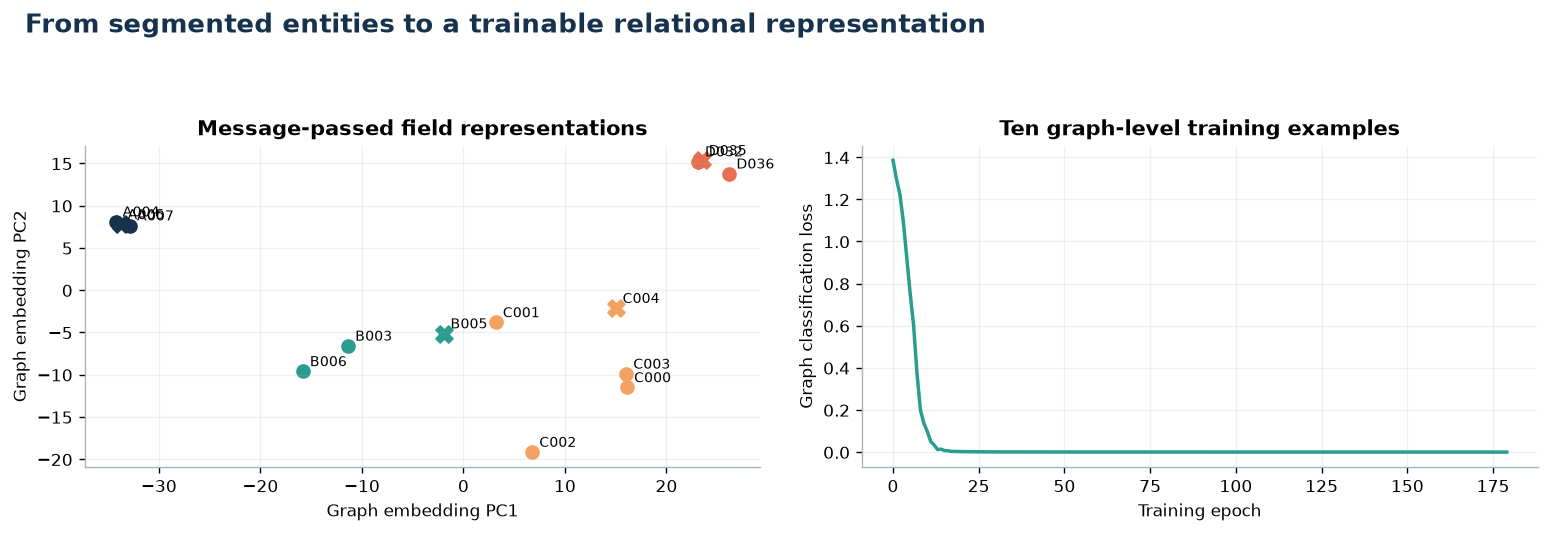

,field,split,nodes used,observed material,predicted material
0,A004,train,153,A,A
1,A005,test,171,A,A
2,A007,train,140,A,A
3,B003,train,180,B,B
4,B005,test,180,B,C
5,B006,train,180,B,B
6,C000,train,180,C,C
7,C001,train,180,C,C
8,C002,train,180,C,C
9,C003,train,180,C,C


GNN material classification on four untouched graphs: 75%. Replace the classifier with a scalar head when enough independent property-linked graphs exist.


In [6]:
node_columns = [
    "area_um2",
    "equivalent_diameter_um",
    "eccentricity",
    "orientation_deg",
    "mean_intensity",
]
edge_columns = ["distance_um", "size_ratio", "intensity_contrast"]
graph_records = []
for pair in carbide_pairs:
    graph = region_graph_from_mask(
        pair["mask"],
        pair["image"],
        pixel_size_um=pair["pixel_size_um"],
        min_area_px=3,
        max_area_fraction=0.05,
        k_neighbours=3,
        max_nodes=180,
    )
    nodes = graph.nodes[node_columns].to_numpy(
        dtype=np.float32, copy=True
    )
    nodes[:, 0] = np.log1p(nodes[:, 0])
    nodes[:, 1] = np.log1p(nodes[:, 1])
    orientation = np.deg2rad(nodes[:, 3])
    nodes = np.column_stack(
        (
            nodes[:, :3],
            np.sin(orientation),
            np.cos(orientation),
            nodes[:, 4],
        )
    ).astype(np.float32)
    edges = graph.edges[edge_columns].to_numpy(
        dtype=np.float32, copy=True
    )
    if len(edges):
        edges[:, 0] = np.log1p(edges[:, 0])
        edge_index = graph.edges[["source", "target"]].to_numpy(
            dtype=np.int64
        )
        reverse = edge_index[:, ::-1]
        edge_index = np.concatenate((edge_index, reverse), axis=0)
        edges = np.concatenate((edges, edges), axis=0)
    else:
        edge_index = np.empty((0, 2), dtype=np.int64)
    graph_records.append(
        {
            "pair": pair,
            "nodes": nodes,
            "edges": edges,
            "edge_index": edge_index,
            "label": material_to_index[pair["material"]],
            "split": (
                "test"
                if (pair["material"], pair["field"]) in validation_keys
                else "train"
            ),
        }
    )

train_nodes = np.concatenate(
    [graph["nodes"] for graph in graph_records if graph["split"] == "train"]
)
train_edges = np.concatenate(
    [
        graph["edges"]
        for graph in graph_records
        if graph["split"] == "train" and len(graph["edges"])
    ]
)
node_mean, node_std = train_nodes.mean(0), train_nodes.std(0) + 1e-6
edge_mean, edge_std = train_edges.mean(0), train_edges.std(0) + 1e-6
for graph in graph_records:
    graph["x"] = torch.from_numpy(
        ((graph["nodes"] - node_mean) / node_std).astype(np.float32)
    ).to(DEVICE)
    graph["edge_attr"] = torch.from_numpy(
        ((graph["edges"] - edge_mean) / edge_std).astype(np.float32)
    ).to(DEVICE)
    graph["edge_index_tensor"] = torch.from_numpy(
        graph["edge_index"].T
    ).long().to(DEVICE)


class MessageLayer(nn.Module):
    def __init__(self, node_dim: int, edge_dim: int, hidden_dim: int):
        super().__init__()
        self.self_projection = nn.Linear(node_dim, hidden_dim)
        self.message = nn.Sequential(
            nn.Linear(node_dim + edge_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(
        self,
        nodes: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
    ) -> torch.Tensor:
        if edge_index.shape[1] == 0:
            return torch.relu(self.self_projection(nodes))
        source, target = edge_index
        messages = self.message(
            torch.cat((nodes[source], edge_attr), dim=1)
        )
        aggregated = torch.zeros(
            (len(nodes), messages.shape[1]),
            device=nodes.device,
        )
        aggregated.index_add_(0, target, messages)
        degree = torch.zeros(len(nodes), device=nodes.device)
        degree.index_add_(
            0,
            target,
            torch.ones(len(target), device=nodes.device),
        )
        aggregated = aggregated / degree.clamp_min(1)[:, None]
        return torch.relu(self.self_projection(nodes) + aggregated)


class CarbideGraphNetwork(nn.Module):
    def __init__(self, node_dim: int, edge_dim: int):
        super().__init__()
        self.layer_1 = MessageLayer(node_dim, edge_dim, 32)
        self.layer_2 = MessageLayer(32, edge_dim, 32)
        self.classifier = nn.Sequential(
            nn.Linear(32, 24),
            nn.ReLU(inplace=True),
            nn.Linear(24, 4),
        )

    def forward(self, graph: dict):
        hidden = self.layer_1(
            graph["x"],
            graph["edge_index_tensor"],
            graph["edge_attr"],
        )
        hidden = self.layer_2(
            hidden,
            graph["edge_index_tensor"],
            graph["edge_attr"],
        )
        graph_embedding = hidden.mean(dim=0)
        return self.classifier(graph_embedding), graph_embedding


torch.manual_seed(101)
graph_model = CarbideGraphNetwork(
    graph_records[0]["x"].shape[1],
    graph_records[0]["edge_attr"].shape[1],
).to(DEVICE)
graph_optimizer = torch.optim.AdamW(
    graph_model.parameters(), lr=3e-3, weight_decay=2e-3
)
graph_history = []
for epoch in range(180):
    losses = []
    graph_model.train()
    order = np.random.default_rng(101 + epoch).permutation(
        [
            index
            for index, graph in enumerate(graph_records)
            if graph["split"] == "train"
        ]
    )
    for index in order:
        graph = graph_records[index]
        graph_optimizer.zero_grad(set_to_none=True)
        logits, _ = graph_model(graph)
        target_label = torch.tensor([graph["label"]], device=DEVICE)
        loss = F.cross_entropy(logits[None], target_label)
        loss.backward()
        graph_optimizer.step()
        losses.append(float(loss.detach().cpu()))
    graph_history.append(float(np.mean(losses)))

graph_rows = []
graph_embeddings = []
graph_model.eval()
with torch.inference_mode():
    for graph in graph_records:
        logits, embedding = graph_model(graph)
        graph_embeddings.append(embedding.cpu().numpy())
        graph_rows.append(
            {
                "field": field_key(graph["pair"]),
                "split": graph["split"],
                "nodes used": len(graph["nodes"]),
                "observed material": graph["pair"]["material"],
                "predicted material": "ABCD"[int(logits.argmax())],
            }
        )
graph_results = pd.DataFrame(graph_rows)
graph_embedding_2d = PCA(n_components=2).fit_transform(
    np.stack(graph_embeddings)
)
graph_test = graph_results.query("split == 'test'")
graph_accuracy = float(
    np.mean(
        graph_test["observed material"]
        == graph_test["predicted material"]
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
for index, graph in enumerate(graph_records):
    material = graph["pair"]["material"]
    marker = "X" if graph["split"] == "test" else "o"
    axes[0].scatter(
        graph_embedding_2d[index, 0],
        graph_embedding_2d[index, 1],
        color=MATERIAL_COLOURS[material],
        marker=marker,
        s=95 if marker == "X" else 55,
    )
    axes[0].annotate(
        field_key(graph["pair"]),
        graph_embedding_2d[index],
        xytext=(4, 3),
        textcoords="offset points",
        fontsize=8,
    )
axes[0].set_xlabel("Graph embedding PC1")
axes[0].set_ylabel("Graph embedding PC2")
axes[0].set_title("Message-passed field representations")
clean_axis(axes[0])
axes[1].plot(graph_history, color=TEAL, linewidth=2)
axes[1].set_xlabel("Training epoch")
axes[1].set_ylabel("Graph classification loss")
axes[1].set_title("Ten graph-level training examples")
clean_axis(axes[1])
fig.suptitle(
    "From segmented entities to a trainable relational representation",
    x=0.02,
    ha="left",
    color=NAVY,
    fontsize=15,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()
display(graph_results)
print(
    f"GNN material classification on four untouched graphs: "
    f"{graph_accuracy:.0%}. Replace the classifier with a scalar head "
    "when enough independent property-linked graphs exist."
)

## 5 · Teacher–student semi-supervised segmentation

The supervised model sees masks from ten fields. A frozen teacher then
proposes pseudo-labels on unmasked carbide-focused crops. Only
high-confidence positive and negative pixels contribute to the
consistency loss, while real masks remain an anchor during student
training.

This short run demonstrates the mechanism and its audit trail. It is
not presented as evidence that pseudo-labels improve the full
segmenter; that requires repeated whole-field evaluation and an expert
review of accepted pseudo-labels.

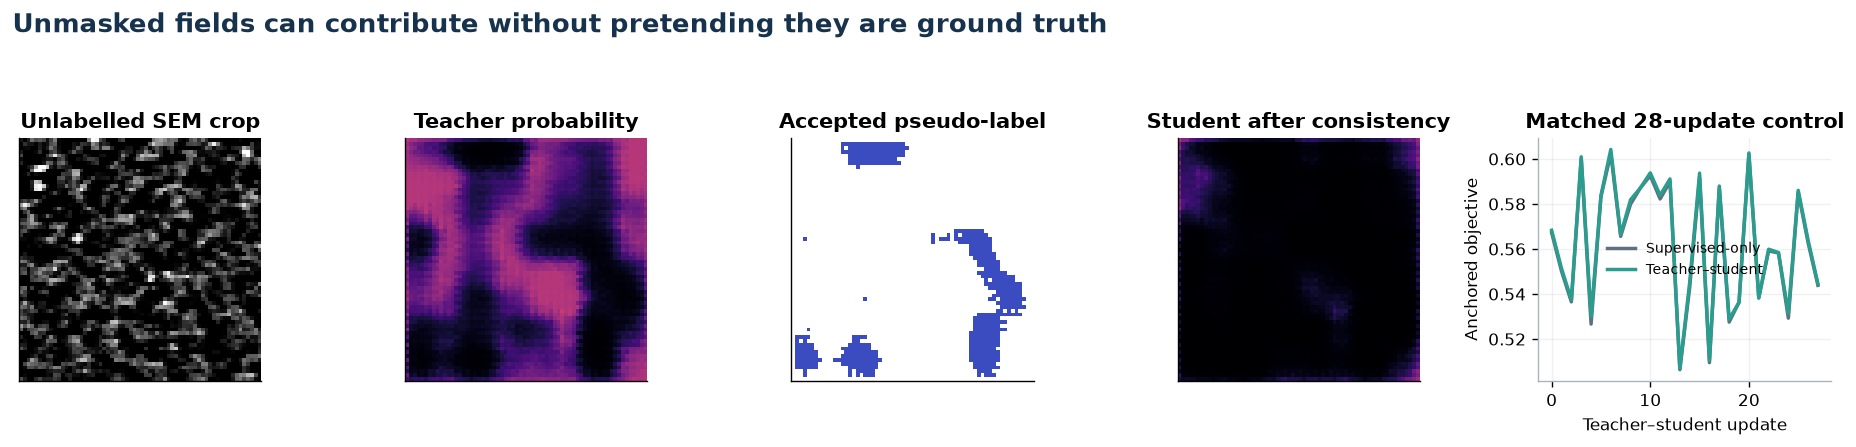

Held-out patch IoU — initial teacher: 0.077; matched supervised-only continuation: 0.472; teacher–student: 0.481. Mean accepted pixel fraction: 15.8%.


In [7]:
class SegmentationPatchDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        pairs: list[dict],
        samples_per_epoch: int = 160,
        seed: int = 113,
    ):
        self.pairs = pairs
        self.samples_per_epoch = samples_per_epoch
        self.seed = seed
        self.epoch = 0
        self.positive_pixels = [
            np.argwhere(pair["mask"]) for pair in pairs
        ]

    def __len__(self):
        return self.samples_per_epoch

    def set_epoch(self, epoch: int):
        self.epoch = epoch

    def __getitem__(self, index: int):
        rng = np.random.default_rng(
            self.seed + self.epoch * self.samples_per_epoch + index
        )
        pair_index = int(rng.integers(len(self.pairs)))
        pair = self.pairs[pair_index]
        if index % 2 == 0 and len(self.positive_pixels[pair_index]):
            centre_y, centre_x = self.positive_pixels[pair_index][
                int(rng.integers(len(self.positive_pixels[pair_index])))
            ]
            centre_y += int(rng.integers(-16, 17))
            centre_x += int(rng.integers(-16, 17))
        else:
            centre_y = int(
                rng.integers(32, int(0.82 * pair["image"].shape[0]) - 32)
            )
            centre_x = int(
                rng.integers(32, pair["image"].shape[1] - 32)
            )
        image = crop_at(
            pair["image"],
            int(centre_y),
            int(centre_x),
            crop_size=64,
        )
        mask = crop_at(
            pair["mask"].astype(np.float32),
            int(centre_y),
            int(centre_x),
            crop_size=64,
        )
        rotations = int(rng.integers(4))
        image, mask = np.rot90(image, rotations), np.rot90(mask, rotations)
        if rng.random() < 0.5:
            image, mask = np.fliplr(image), np.fliplr(mask)
        return (
            torch.from_numpy(np.ascontiguousarray(image[None])).float(),
            torch.from_numpy(np.ascontiguousarray(mask[None])).float(),
        )


class TinySegmenter(nn.Module):
    def __init__(self, encoder: TinyEncoder):
        super().__init__()
        self.encoder = copy.deepcopy(encoder)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(16, 8, 4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(8, 1, 4, stride=2, padding=1),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder.feature_map(inputs))


def segmentation_loss(logits: torch.Tensor, targets: torch.Tensor):
    positive_weight = torch.tensor([8.0], device=logits.device)
    bce = F.binary_cross_entropy_with_logits(
        logits, targets, pos_weight=positive_weight
    )
    probability = torch.sigmoid(logits)
    intersection = (probability * targets).sum((1, 2, 3))
    denominator = probability.sum((1, 2, 3)) + targets.sum((1, 2, 3))
    dice = 1 - (
        (2 * intersection + 1) / (denominator + 1)
    ).mean()
    return 0.45 * bce + 0.55 * dice


supervised_dataset = SegmentationPatchDataset(train_pairs)
supervised_loader = torch.utils.data.DataLoader(
    supervised_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
)
torch.manual_seed(113)
teacher = TinySegmenter(mae_encoder).to(DEVICE)
teacher_optimizer = torch.optim.AdamW(
    teacher.parameters(), lr=2e-3, weight_decay=1e-4
)
supervised_history = []
for epoch in range(8):
    supervised_dataset.set_epoch(epoch)
    teacher.train()
    losses = []
    for image_batch, mask_batch in supervised_loader:
        teacher_optimizer.zero_grad(set_to_none=True)
        loss = segmentation_loss(
            teacher(image_batch.to(DEVICE)),
            mask_batch.to(DEVICE),
        )
        loss.backward()
        teacher_optimizer.step()
        losses.append(float(loss.detach().cpu()))
    supervised_history.append(float(np.mean(losses)))

evaluation_dataset = SegmentationPatchDataset(
    test_pairs,
    samples_per_epoch=80,
    seed=211,
)
evaluation_loader = torch.utils.data.DataLoader(
    evaluation_dataset,
    batch_size=20,
    shuffle=False,
    num_workers=0,
)


@torch.inference_mode()
def patch_iou(model: nn.Module) -> float:
    model.eval()
    intersection = 0
    union = 0
    for images, masks in evaluation_loader:
        prediction = (
            torch.sigmoid(model(images.to(DEVICE))).cpu() >= 0.5
        )
        truth = masks >= 0.5
        intersection += int(torch.count_nonzero(prediction & truth))
        union += int(torch.count_nonzero(prediction | truth))
    return intersection / max(1, union)


teacher_iou = patch_iou(teacher)
supervised_control = copy.deepcopy(teacher)
student = copy.deepcopy(teacher)
control_optimizer = torch.optim.AdamW(
    supervised_control.parameters(), lr=5e-4, weight_decay=1e-4
)
student_optimizer = torch.optim.AdamW(
    student.parameters(), lr=5e-4, weight_decay=1e-4
)
pseudo_rng = np.random.default_rng(227)
supervised_iterator = iter(supervised_loader)
pseudo_history = []
control_history = []
pseudo_acceptance = []
teacher.eval()
for step in range(28):
    indices = pseudo_rng.integers(0, len(ssl_patches), size=16)
    clean = torch.from_numpy(
        ssl_patches[indices, None].astype(np.float32) / 255.0
    ).to(DEVICE)
    noisy = torch.clamp(
        clean + 0.035 * torch.randn_like(clean), 0, 1
    )
    with torch.inference_mode():
        teacher_probability = torch.sigmoid(teacher(clean))
    positive = teacher_probability >= 0.78
    negative = teacher_probability <= 0.04
    accepted = positive | negative

    try:
        supervised_images, supervised_masks = next(supervised_iterator)
    except StopIteration:
        supervised_iterator = iter(supervised_loader)
        supervised_images, supervised_masks = next(supervised_iterator)

    supervised_control.train()
    control_optimizer.zero_grad(set_to_none=True)
    control_objective = segmentation_loss(
        supervised_control(supervised_images.to(DEVICE)),
        supervised_masks.to(DEVICE),
    )
    control_objective.backward()
    control_optimizer.step()
    control_history.append(float(control_objective.detach().cpu()))

    student.train()
    student_optimizer.zero_grad(set_to_none=True)
    supervised_objective = segmentation_loss(
        student(supervised_images.to(DEVICE)),
        supervised_masks.to(DEVICE),
    )
    pseudo_logits = student(noisy)
    if torch.count_nonzero(accepted):
        pseudo_targets = positive.float()
        consistency_objective = F.binary_cross_entropy_with_logits(
            pseudo_logits[accepted],
            pseudo_targets[accepted],
        )
    else:
        consistency_objective = F.mse_loss(
            torch.sigmoid(pseudo_logits), teacher_probability
        )
    loss = supervised_objective + 0.25 * consistency_objective
    loss.backward()
    student_optimizer.step()
    pseudo_history.append(float(loss.detach().cpu()))
    pseudo_acceptance.append(float(accepted.float().mean().cpu()))

control_iou = patch_iou(supervised_control)
student_iou = patch_iou(student)

candidate_tensor = torch.from_numpy(
    ssl_patches[:64, None].astype(np.float32) / 255.0
).to(DEVICE)
with torch.inference_mode():
    candidate_probability = torch.sigmoid(teacher(candidate_tensor))
    candidate_score = candidate_probability.flatten(1).amax(1)
    shown_index = int(candidate_score.argmax())
    shown_teacher = candidate_probability[shown_index, 0].cpu().numpy()
    shown_student = torch.sigmoid(
        student(candidate_tensor[shown_index : shown_index + 1])
    )[0, 0].cpu().numpy()
shown_raw = candidate_tensor[shown_index, 0].cpu().numpy()
shown_confident = np.where(
    shown_teacher >= 0.78,
    1.0,
    np.where(shown_teacher <= 0.04, 0.0, np.nan),
)

fig, axes = plt.subplots(1, 5, figsize=(15, 3.6))
panels = [
    (shown_raw, "Unlabelled SEM crop", "gray"),
    (shown_teacher, "Teacher probability", "magma"),
    (shown_confident, "Accepted pseudo-label", "coolwarm"),
    (shown_student, "Student after consistency", "magma"),
]
for axis, (panel, title, cmap) in zip(axes[:4], panels, strict=True):
    axis.imshow(panel, cmap=cmap, vmin=0, vmax=1)
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
axes[4].plot(
    control_history,
    color=SLATE,
    linewidth=2,
    label="Supervised-only",
)
axes[4].plot(
    pseudo_history,
    color=TEAL,
    linewidth=2,
    label="Teacher–student",
)
axes[4].set_xlabel("Teacher–student update")
axes[4].set_ylabel("Anchored objective")
axes[4].set_title("Matched 28-update control")
axes[4].legend(fontsize=8)
clean_axis(axes[4])
fig.suptitle(
    "Unmasked fields can contribute without pretending they are ground truth",
    x=0.02,
    ha="left",
    color=NAVY,
    fontsize=15,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()
print(
    f"Held-out patch IoU — initial teacher: {teacher_iou:.3f}; "
    f"matched supervised-only continuation: {control_iou:.3f}; "
    f"teacher–student: {student_iou:.3f}. "
    f"Mean accepted pixel fraction: {np.mean(pseudo_acceptance):.1%}."
)

## 6 · Registered local properties, conformal intervals, and active learning

This section mimics a registered indentation campaign:

1. divide one real SEM/mask into physical neighbourhoods;
2. attach one local response to each neighbourhood;
3. hold out spatial blocks rather than random pixels;
4. calibrate prediction intervals on a separate spatial block;
5. rank the next locations by model disagreement and distance from the
   training distribution.

**Important:** the local hardness values below are simulated from the
real carbide morphology plus noise. They exist only to exercise the
workflow until registered indentation data are collected.

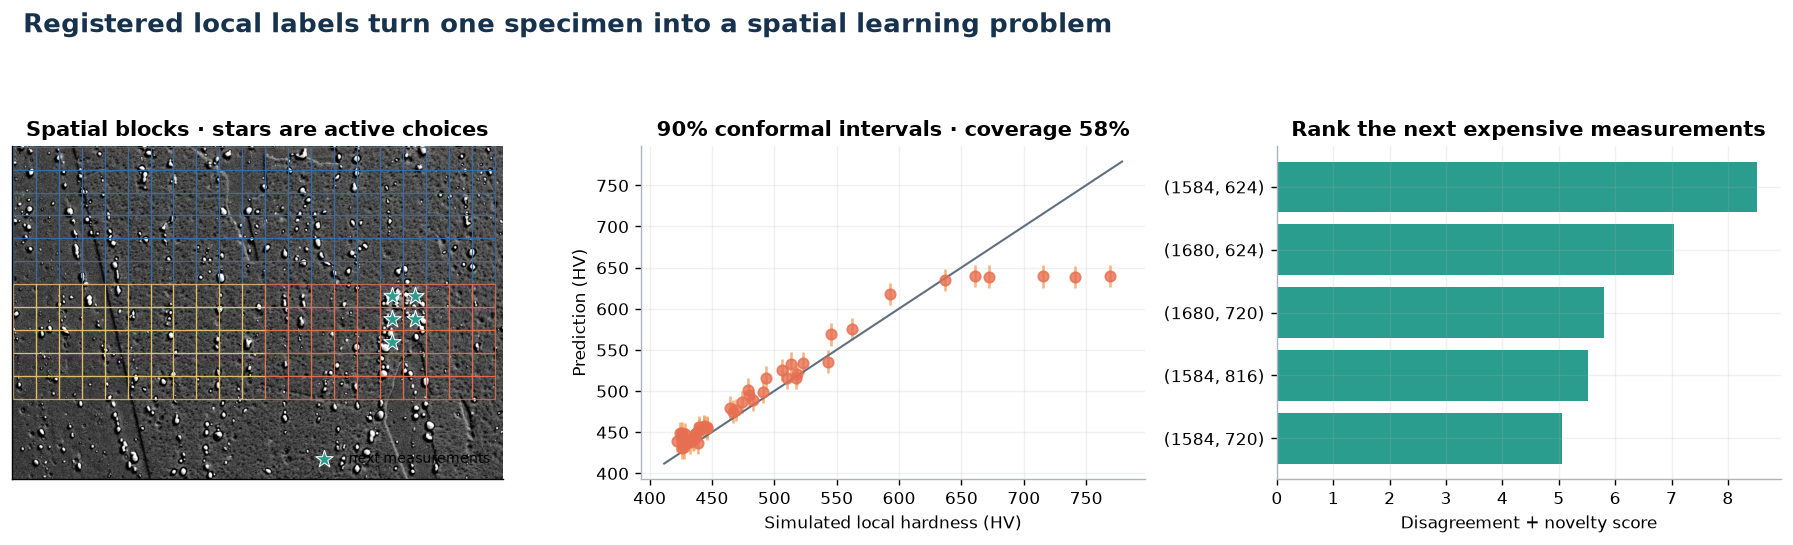

,value
spatial neighbourhoods,231.000
training neighbourhoods,126.000
calibration neighbourhoods,55.000
test neighbourhoods,50.000
test MAE (simulated HV),18.069
90% interval radius (HV),13.606
held-out spatial coverage,0.580


In [8]:
spatial_pair = next(pair for pair in carbide_pairs if field_key(pair) == "D035")
patch_size = 96
spatial_rng = np.random.default_rng(307)
spatial_rows = []
content_height = int(0.82 * spatial_pair["image"].shape[0])
for top in range(0, content_height - patch_size + 1, patch_size):
    for left in range(
        0,
        spatial_pair["image"].shape[1] - patch_size + 1,
        patch_size,
    ):
        image_patch = spatial_pair["image"][
            top : top + patch_size,
            left : left + patch_size,
        ]
        mask_patch = spatial_pair["mask"][
            top : top + patch_size,
            left : left + patch_size,
        ]
        labels, n_regions = ndimage.label(mask_patch)
        areas = np.bincount(labels.ravel())[1:]
        areas = areas[areas >= 3]
        gradient_y, gradient_x = np.gradient(image_patch)
        gradient_mean = float(
            np.hypot(gradient_x, gradient_y).mean()
        )
        area_pct = float(100 * mask_patch.mean())
        mean_particle_area = float(areas.mean()) if len(areas) else 0.0
        centre_y = top + patch_size / 2
        centre_x = left + patch_size / 2
        x_fraction = centre_x / spatial_pair["image"].shape[1]
        y_fraction = centre_y / content_height
        # Synthetic response: morphology-dependent, spatially smooth,
        # and noisy enough to make uncertainty meaningful.
        simulated_hardness = (
            430
            + 24 * area_pct
            + 0.18 * len(areas)
            + 0.35 * np.sqrt(mean_particle_area)
            + 45 * gradient_mean
            + 8 * np.sin(2 * np.pi * x_fraction)
            + 5 * np.cos(np.pi * y_fraction)
            + spatial_rng.normal(0, 5.0)
        )
        block = (
            2 * int(centre_y >= content_height / 2)
            + int(centre_x >= spatial_pair["image"].shape[1] / 2)
        )
        spatial_rows.append(
            {
                "top": top,
                "left": left,
                "centre_y": centre_y,
                "centre_x": centre_x,
                "block": block,
                "area_pct": area_pct,
                "particle_count": float(len(areas)),
                "mean_particle_area": mean_particle_area,
                "intensity_mean": float(image_patch.mean()),
                "intensity_std": float(image_patch.std()),
                "gradient_mean": gradient_mean,
                "simulated_hardness_hv": simulated_hardness,
            }
        )
spatial_frame = pd.DataFrame(spatial_rows)
local_feature_columns = [
    "area_pct",
    "particle_count",
    "mean_particle_area",
    "intensity_mean",
    "intensity_std",
    "gradient_mean",
]
train_local = spatial_frame["block"].isin([0, 1])
calibration_local = spatial_frame["block"] == 2
test_local = spatial_frame["block"] == 3

local_model = RandomForestRegressor(
    n_estimators=240,
    min_samples_leaf=2,
    max_features=0.8,
    random_state=307,
)
local_feature_matrix = spatial_frame[local_feature_columns].to_numpy()
train_local_array = train_local.to_numpy()
local_model.fit(
    local_feature_matrix[train_local_array],
    spatial_frame.loc[train_local, "simulated_hardness_hv"],
)
spatial_frame["prediction_hv"] = local_model.predict(
    local_feature_matrix
)
calibration_residual = np.abs(
    spatial_frame.loc[calibration_local, "simulated_hardness_hv"]
    - spatial_frame.loc[calibration_local, "prediction_hv"]
)
n_calibration = len(calibration_residual)
quantile_level = min(
    1.0,
    math.ceil((n_calibration + 1) * 0.90) / n_calibration,
)
conformal_radius = float(
    np.quantile(
        calibration_residual,
        quantile_level,
        method="higher",
    )
)
test_error = np.abs(
    spatial_frame.loc[test_local, "simulated_hardness_hv"]
    - spatial_frame.loc[test_local, "prediction_hv"]
)
conformal_coverage = float(np.mean(test_error <= conformal_radius))

tree_predictions = np.stack(
    [
        tree.predict(local_feature_matrix)
        for tree in local_model.estimators_
    ]
)
spatial_frame["ensemble_std"] = tree_predictions.std(axis=0)
scaler_local = StandardScaler().fit(
    spatial_frame.loc[train_local, local_feature_columns]
)
scaled_all = scaler_local.transform(
    spatial_frame[local_feature_columns]
)
train_scaled = scaled_all[train_local.to_numpy()]
spatial_frame["nearest_train_distance"] = cdist(
    scaled_all, train_scaled
).min(axis=1)
candidate = ~train_local
for column in ("ensemble_std", "nearest_train_distance"):
    values = spatial_frame.loc[candidate, column]
    spatial_frame.loc[candidate, f"{column}_z"] = (
        values - values.mean()
    ) / (values.std() + 1e-9)
spatial_frame["active_score"] = (
    spatial_frame["ensemble_std_z"].fillna(-np.inf)
    + spatial_frame["nearest_train_distance_z"].fillna(-np.inf)
)
next_locations = spatial_frame.loc[candidate].nlargest(
    5, "active_score"
)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4))
axes[0].imshow(spatial_pair["image"], cmap="gray")
for row in spatial_frame.itertuples(index=False):
    colour = {0: BLUE, 1: BLUE, 2: GOLD, 3: RED}[row.block]
    axes[0].add_patch(
        Rectangle(
            (row.left, row.top),
            patch_size,
            patch_size,
            fill=False,
            edgecolor=colour,
            linewidth=0.7,
            alpha=0.8,
        )
    )
axes[0].scatter(
    next_locations["centre_x"],
    next_locations["centre_y"],
    marker="*",
    s=110,
    color=TEAL,
    edgecolor="white",
    linewidth=0.6,
    label="next measurements",
)
axes[0].legend(loc="lower right", fontsize=8)
axes[0].set_title("Spatial blocks · stars are active choices")
axes[0].set_xticks([])
axes[0].set_yticks([])

observed_test = spatial_frame.loc[
    test_local, "simulated_hardness_hv"
]
predicted_test = spatial_frame.loc[test_local, "prediction_hv"]
axes[1].errorbar(
    observed_test,
    predicted_test,
    yerr=conformal_radius,
    fmt="o",
    color=RED,
    ecolor=ORANGE,
    alpha=0.8,
)
plot_low = min(observed_test.min(), predicted_test.min()) - 10
plot_high = max(observed_test.max(), predicted_test.max()) + 10
axes[1].plot(
    [plot_low, plot_high],
    [plot_low, plot_high],
    color=SLATE,
    linewidth=1.2,
)
axes[1].set_xlabel("Simulated local hardness (HV)")
axes[1].set_ylabel("Prediction (HV)")
axes[1].set_title(
    f"90% conformal intervals · coverage {conformal_coverage:.0%}"
)
clean_axis(axes[1])

score_plot = next_locations.sort_values("active_score")
axes[2].barh(
    [
        f"({int(row.centre_x)}, {int(row.centre_y)})"
        for row in score_plot.itertuples()
    ],
    score_plot["active_score"],
    color=TEAL,
)
axes[2].set_xlabel("Disagreement + novelty score")
axes[2].set_title("Rank the next expensive measurements")
clean_axis(axes[2])
fig.suptitle(
    "Registered local labels turn one specimen into a spatial learning problem",
    x=0.02,
    ha="left",
    color=NAVY,
    fontsize=15,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

local_summary = pd.Series(
    {
        "spatial neighbourhoods": len(spatial_frame),
        "training neighbourhoods": int(train_local.sum()),
        "calibration neighbourhoods": int(calibration_local.sum()),
        "test neighbourhoods": int(test_local.sum()),
        "test MAE (simulated HV)": mean_absolute_error(
            observed_test, predicted_test
        ),
        "90% interval radius (HV)": conformal_radius,
        "held-out spatial coverage": conformal_coverage,
    },
    name="value",
)
display(local_summary.to_frame().round(3))

## 7 · Multimodal fusion on real IN718 hardness

The Godec IN718 series provides ten real hardness states and 22 linked
BSE-SEM images. Three models are compared while holding out both
Gaussian- and ring-beam versions of one thermal condition together:

- process metadata only;
- frozen self-supervised image embeddings only;
- early and late process–image fusion.

This is deliberately an ablation, not an invitation to concatenate
every available column. A modality earns its place only if it improves
unseen-condition prediction.

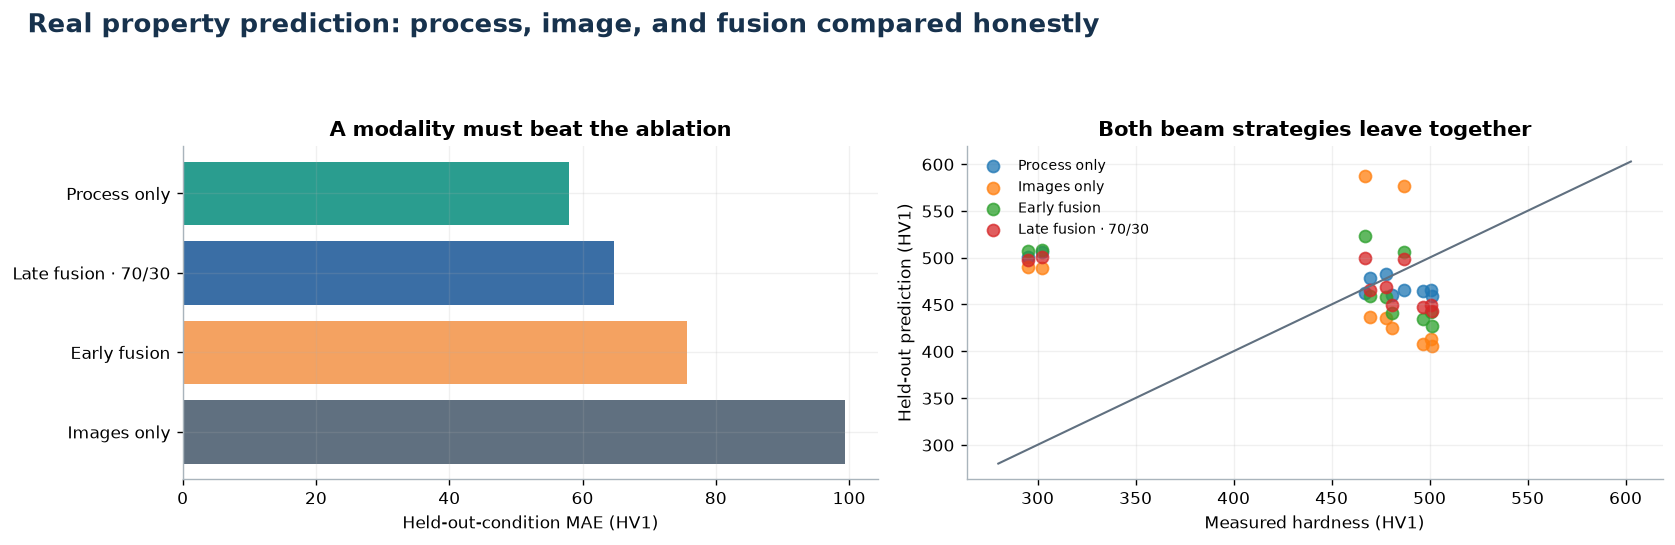

,held-out-condition MAE (HV1)
Process only,57.9
Late fusion · 70/30,64.7
Early fusion,75.8
Images only,99.4


In [9]:
godec_root = DATA / "public_in718_godec_2024"
hardness = pd.read_csv(godec_root / "hardness.csv")
hardness["condition"] = hardness["temperature_c"].apply(
    lambda value: "AB" if pd.isna(value) else str(int(value))
)


def godec_image_record(path: Path) -> dict:
    parts = path.stem.split()
    if parts[1] == "AB":
        condition = "AB"
        strategy = parts[2]
    else:
        condition = parts[2]
        strategy = parts[3]
    with Image.open(path) as image:
        array = normalise_grayscale(
            np.asarray(image.convert("L"))
        ).astype(np.float32)
    y_positions = np.linspace(80, int(0.76 * array.shape[0]), 3).astype(int)
    x_positions = np.linspace(80, array.shape[1] - 80, 3).astype(int)
    patches = np.stack(
        [
            crop_at(array, int(y), int(x), crop_size=64)
            for y in y_positions
            for x in x_positions
        ]
    )
    embedding = encode_arrays(mae_encoder, patches).mean(axis=0)
    gradient_y, gradient_x = np.gradient(array)
    texture = np.array(
        [
            array.mean(),
            array.std(),
            np.quantile(array, 0.1),
            np.quantile(array, 0.9),
            np.hypot(gradient_x, gradient_y).mean(),
        ],
        dtype=np.float32,
    )
    return {
        "path": path,
        "condition": condition,
        "build_strategy": strategy,
        "embedding": embedding,
        "texture": texture,
    }


godec_images = [
    godec_image_record(path)
    for path in sorted((godec_root / "raw").glob("*.tif"))
]
state_rows = []
for (condition, strategy), records in pd.DataFrame(
    [
        {
            "condition": record["condition"],
            "build_strategy": record["build_strategy"],
            "record": record,
        }
        for record in godec_images
    ]
).groupby(["condition", "build_strategy"]):
    state_rows.append(
        {
            "condition": condition,
            "build_strategy": strategy,
            "image_count": len(records),
            "image_embedding": np.mean(
                [record["embedding"] for record in records["record"]],
                axis=0,
            ),
            "texture": np.mean(
                [record["texture"] for record in records["record"]],
                axis=0,
            ),
        }
    )
state_frame = pd.DataFrame(state_rows)
state_frame = state_frame.merge(
    hardness[
        [
            "condition",
            "build_strategy",
            "temperature_c",
            "hardness_hv",
        ]
    ],
    on=["condition", "build_strategy"],
    how="inner",
    validate="one_to_one",
).sort_values(["condition", "build_strategy"]).reset_index(drop=True)

process_features = np.column_stack(
    (
        (state_frame["condition"] == "AB").astype(float),
        state_frame["temperature_c"].fillna(0).to_numpy() / 1000,
        (state_frame["build_strategy"] == "Ring").astype(float),
    )
)
image_features = np.stack(state_frame["image_embedding"])
texture_features = np.stack(state_frame["texture"])
image_modality = np.concatenate((image_features, texture_features), axis=1)
fusion_features = np.concatenate((process_features, image_modality), axis=1)
hardness_target = state_frame["hardness_hv"].to_numpy()
condition_groups = state_frame["condition"].to_numpy()
condition_cv = GroupKFold(n_splits=5)

process_model = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
image_model = make_pipeline(
    StandardScaler(),
    PCA(n_components=4),
    Ridge(alpha=10.0),
)
fusion_model = make_pipeline(StandardScaler(), Ridge(alpha=25.0))
process_prediction = cross_val_predict(
    process_model,
    process_features,
    hardness_target,
    groups=condition_groups,
    cv=condition_cv,
)
image_prediction = cross_val_predict(
    image_model,
    image_modality,
    hardness_target,
    groups=condition_groups,
    cv=condition_cv,
)
early_fusion_prediction = cross_val_predict(
    fusion_model,
    fusion_features,
    hardness_target,
    groups=condition_groups,
    cv=condition_cv,
)
late_fusion_prediction = 0.70 * process_prediction + 0.30 * image_prediction

modality_predictions = {
    "Process only": process_prediction,
    "Images only": image_prediction,
    "Early fusion": early_fusion_prediction,
    "Late fusion · 70/30": late_fusion_prediction,
}
modality_scores = pd.Series(
    {
        name: mean_absolute_error(hardness_target, prediction)
        for name, prediction in modality_predictions.items()
    },
    name="held-out-condition MAE (HV1)",
).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
axes[0].barh(
    modality_scores.index,
    modality_scores,
    color=[TEAL, BLUE, ORANGE, SLATE],
)
axes[0].invert_yaxis()
axes[0].set_xlabel("Held-out-condition MAE (HV1)")
axes[0].set_title("A modality must beat the ablation")
clean_axis(axes[0])

for name, prediction in modality_predictions.items():
    axes[1].scatter(
        hardness_target,
        prediction,
        s=48,
        alpha=0.75,
        label=name,
    )
low = min(
    hardness_target.min(),
    min(prediction.min() for prediction in modality_predictions.values()),
) - 15
high = max(
    hardness_target.max(),
    max(prediction.max() for prediction in modality_predictions.values()),
) + 15
axes[1].plot([low, high], [low, high], color=SLATE, linewidth=1.2)
axes[1].set_xlabel("Measured hardness (HV1)")
axes[1].set_ylabel("Held-out prediction (HV1)")
axes[1].set_title("Both beam strategies leave together")
axes[1].legend(fontsize=8)
clean_axis(axes[1])
fig.suptitle(
    "Real property prediction: process, image, and fusion compared honestly",
    x=0.02,
    ha="left",
    color=NAVY,
    fontsize=15,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()
display(modality_scores.to_frame().round(1))

## 8 · Domain alignment—and why the domain label matters

CORAL is a simple unsupervised domain-adaptation method: whiten source
features and recolour them with the covariance of an unlabelled target
domain. Here Gaussian-beam states are treated as the source and
ring-beam states as the target.

This is intentionally also a warning. Beam strategy changes the
material, not merely the camera. If alignment removes genuine process
information, performance can worsen. Proper microscope adaptation
should align acquisition effects while preserving alloy and processing
effects.

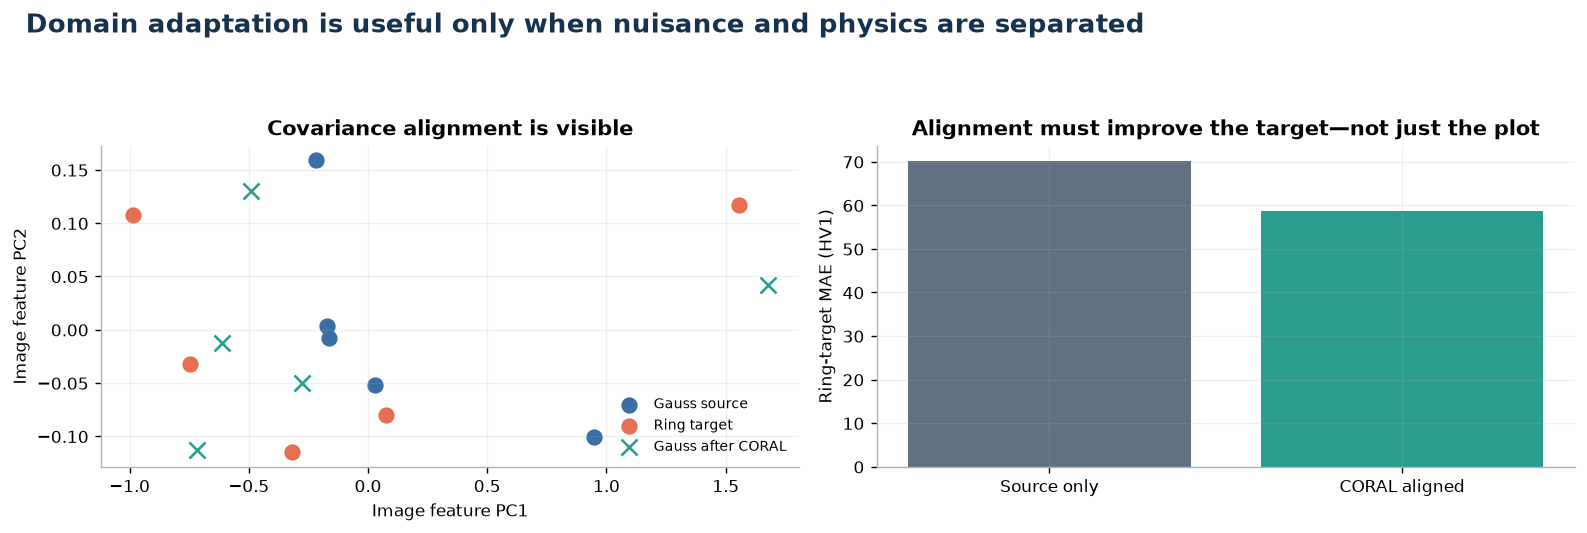

,Ring-target MAE (HV1)
Source only,70.2
CORAL aligned,58.7


In [10]:
def symmetric_matrix_power(matrix: np.ndarray, power: float) -> np.ndarray:
    values, vectors = np.linalg.eigh(matrix)
    values = np.clip(values, 1e-6, None) ** power
    return (vectors * values) @ vectors.T


def coral_source_to_target(
    source: np.ndarray,
    target: np.ndarray,
) -> np.ndarray:
    source_mean = source.mean(0)
    target_mean = target.mean(0)
    source_cov = np.cov(source - source_mean, rowvar=False) + 1e-3 * np.eye(
        source.shape[1]
    )
    target_cov = np.cov(target - target_mean, rowvar=False) + 1e-3 * np.eye(
        target.shape[1]
    )
    return (
        (source - source_mean)
        @ symmetric_matrix_power(source_cov, -0.5)
        @ symmetric_matrix_power(target_cov, 0.5)
        + target_mean
    )


source_index = state_frame["build_strategy"] == "Gauss"
target_index = state_frame["build_strategy"] == "Ring"
domain_pca = PCA(n_components=3).fit(image_modality)
source_domain = domain_pca.transform(image_modality[source_index])
target_domain = domain_pca.transform(image_modality[target_index])
aligned_source = coral_source_to_target(source_domain, target_domain)
source_target = hardness_target[source_index]
target_target = hardness_target[target_index]

source_only_model = make_pipeline(StandardScaler(), Ridge(alpha=5.0))
source_only_model.fit(source_domain, source_target)
source_only_prediction = source_only_model.predict(target_domain)
aligned_model = make_pipeline(StandardScaler(), Ridge(alpha=5.0))
aligned_model.fit(aligned_source, source_target)
aligned_prediction = aligned_model.predict(target_domain)
domain_scores = pd.Series(
    {
        "Source only": mean_absolute_error(
            target_target, source_only_prediction
        ),
        "CORAL aligned": mean_absolute_error(
            target_target, aligned_prediction
        ),
    },
    name="Ring-target MAE (HV1)",
)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.3))
axes[0].scatter(
    source_domain[:, 0],
    source_domain[:, 1],
    color=BLUE,
    s=70,
    label="Gauss source",
)
axes[0].scatter(
    target_domain[:, 0],
    target_domain[:, 1],
    color=RED,
    s=70,
    label="Ring target",
)
axes[0].scatter(
    aligned_source[:, 0],
    aligned_source[:, 1],
    color=TEAL,
    marker="x",
    s=85,
    label="Gauss after CORAL",
)
axes[0].set_xlabel("Image feature PC1")
axes[0].set_ylabel("Image feature PC2")
axes[0].set_title("Covariance alignment is visible")
axes[0].legend(fontsize=8)
clean_axis(axes[0])

axes[1].bar(
    domain_scores.index,
    domain_scores,
    color=[SLATE, TEAL],
)
axes[1].set_ylabel("Ring-target MAE (HV1)")
axes[1].set_title("Alignment must improve the target—not just the plot")
clean_axis(axes[1])
fig.suptitle(
    "Domain adaptation is useful only when nuisance and physics are separated",
    x=0.02,
    ha="left",
    color=NAVY,
    fontsize=15,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()
display(domain_scores.to_frame().round(1))

## 9 · What this small notebook establishes

| Technique | Data used here | Demonstrated output | Claim level |
|---|---|---|---|
| Masked / contrastive SSL | Real unlabelled SEM | Frozen representation probes | Small benchmark |
| Scale-aware representation | Fine + contextual crops + scale token | Whole-field classification | Architecture demonstration |
| Attention MIL | Real fields as patch bags | Learned patch importance | Material task, not property |
| Entity GNN | Real carbide nodes and edges | Message-passed graph embeddings | Material task, not property |
| Semi-supervised segmentation | Real masks + unmasked fields | Auditable pseudo-label consistency | Mechanism demonstration |
| Registered property mapping | Real SEM/mask + simulated HV | Spatial prediction map | Synthetic property only |
| Conformal + active learning | Simulated spatial HV | Intervals and next locations | Workflow demonstration |
| Multimodal fusion | Real process, SEM and HV1 | Held-out-condition ablation | Small real property test |
| Domain adaptation | Real Gauss/Ring embeddings | CORAL alignment and target MAE | Cautionary proxy domain |

### The next full experiments

1. Replace simulated local hardness with a registered indentation grid.
2. Scale masked pretraining to all eligible SEM crops with ConvNeXtV2.
3. Train MIL and the entity GNN on independently linked specimen
   properties—not repeated condition labels.
4. Evaluate microscope/domain transfer on an external alloy family.
5. Calibrate intervals only after a genuinely separate calibration
   cohort exists.

The notebook deliberately stops before conditional diffusion or inverse
design. Those become scientifically meaningful after the forward
process–structure–property model survives external validation.

**Literature anchors:** [MicroNet](https://doi.org/10.1038/s41524-022-00878-5) ·
[SEM self-supervision](https://doi.org/10.1038/s41524-025-01802-3) ·
[attention MIL](https://arxiv.org/abs/1802.04712) ·
[microstructure GNN](https://doi.org/10.1038/s41524-021-00574-w) ·
[registered hardness mapping](https://doi.org/10.1038/s43246-026-01259-x)